In [14]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [15]:
load_dotenv()

True

In [16]:
model = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [17]:
MAX_TOKENS = 150

In [18]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content) 

    response = model.invoke(messages)

    return {"messages": [response]}

In [19]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [20]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

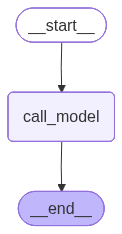

In [21]:
graph

In [22]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Tanish."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Tanish.


"Hi Tanish, it's nice to meet you! How can I help you today?"

In [23]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 40
Hi, my name is Tanish.
Hi Tanish, it's nice to meet you! How can I help you today?
I am learning LangGraph.


"That's fantastic, Tanish! LangGraph is a really powerful and exciting library for building complex, stateful applications with LLMs. It's designed to help you manage the flow of information and logic in multi-turn conversations or more intricate agentic workflows.\n\nWhat specifically are you working on or curious about with LangGraph? Are you:\n\n*   **Just starting out and want to understand the core concepts?** (e.g., nodes, edges, states, the graph builder)\n*   **Trying to build a specific type of application?** (e.g., a chatbot, a multi-agent system, a data analysis pipeline)\n*   **Encountering a particular problem or have a question about a specific feature?**\n*   **Looking for examples or best practices?**\n\nThe more you can tell me about your learning journey, the better I can assist you!"

In [24]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is a crucial cognitive system that allows us to **hold and manipulate a small amount of information for a brief period of time.** Think of it as your brain\'s temporary scratchpad or a mental workbench. It\'s where you keep things "on hand" for immediate use.\n\nHere\'s a breakdown of its key characteristics and functions:\n\n**Key Characteristics of Short-Term Memory:**\n\n*   **Limited Capacity:** This is the most defining feature. STM can only hold a relatively small amount of information at any given moment. The classic estimate, proposed by George Miller, is around **7 plus or minus 2 items (7±2)**. This means you can typically hold between 5 and 9 pieces of information (like numbers, words, or concepts) in your STM at once. More recent research suggests this capacity might be even smaller, closer to 4 items, especially when considering complex information.\n*   **Limited Duration:** Information in STM doesn\'t stay there forever. If you don\'t actively re

In [25]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I do not have access to any personal information about you, including your name. I am a large language model, trained by Google.'

In [26]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Tanish.
------------------------------------------------------------------------------------------------------------------------
Hi Tanish, it's nice to meet you! How can I help you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's fantastic, Tanish! LangGraph is a really powerful and exciting library for building complex, stateful applications with LLMs. It's designed to help you manage the flow of information and logic in multi-turn conversations or more intricate agentic workflows.

What specifically are you working on or curious about with LangGraph? Are you:

*   **Just starting out and want to understand the core concepts?** (e.g., nodes, edges, states, the graph builder)
*   **Trying to build a specific type of application?** (e.g., a ch